In [1]:
import jax
import equinox as eqx
import numpy as np
import jax.numpy as jnp
import immrax as irx
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import cvxpy as cp
import scipy
from immutabledict import immutabledict
from reach import *
from functools import partial
import control
from GPR import *
from TVGPR import *

# Some configurations
jax.config.update("jax_enable_x64", True)

# We wrap the jax.jit function t/o set the backend to cpu by default for convenience.
device = 'cpu'
def jit (*args, **kwargs):
    kwargs.setdefault('backend', device)
    return jax.jit(*args, **kwargs)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 14
})

np.random.seed(0)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# system dynamics and initial conditions

class PlanarMultirotor (irx.System) :
    def __init__ (self) :
        self.xlen = 5
        self.evolution = 'continuous'

    def f(self, t, x, u, w):
        px, py, vx, vy, theta = x.ravel()
        u1, u2 = u.ravel()
        w1 = w[0]
        g = 9.81

        return jnp.array([
            vx,
            vy,
            -1*u1*jnp.sin(theta) + w1,
            u1*jnp.cos(theta) - g,
            u2
        ])

sys = PlanarMultirotor()

# initial conditions
x0 = jnp.array([1., 0.5, 0., 0., 0.1])
u0 = jnp.array([11.0, 0.])

w0 = jnp.array([0.0])

# x0_buf = 0.05 * jnp.array([1.0, 1.0, 1.0, 1.0, 1.0])
x0_buf = jnp.array([0.01, 0.01, 0.01, 0.01, 0.01])
ix0 = irx.icentpert(x0, x0_buf)
print(ix0)

GP = GPR(jnp.array([[0.0, 1.], [1.0, 1.0], [-1.0, 1.]]))

[[( 0.99, 1.01)]
 [( 0.49, 0.51)]
 [(-0.01, 0.01)]
 [(-0.01, 0.01)]
 [( 0.09, 0.11)]]


In [3]:
def disturbance (t, x) :
    return GP.mean(jnp.array([x[1]])).reshape(-1)
    # return GP.mean(x[(0,),])
print(ix0[(0,),])
print(x0[0])

def tr (x) :
    # return x[(0,),]
    return jnp.array([x[0]])

# print(tr(ix0))
print(irx.natif(tr)(ix0))
print(disturbance(0.0, x0))

[[(0.99, 1.01)]]
1.0
[[(0.99, 1.01)]]
[1.01703524]


In [ ]:
# Get initial P, K from LQR

# linearize system around x0, u0
A, B = jax.jacfwd(lambda x: sys.f(0, x, u0, w0))(x0), jax.jacfwd(lambda u: sys.f(0, x0, u, w0))(u0)
# print(A)
# print(B)

# weight matrices
Q = jnp.array([1, 1, 1, 1, 1]) * jnp.eye(sys.xlen)
R = jnp.array([1, 1]) * jnp.eye(2)

# LQR to get initial K, P
K, P, _ = control.lqr(A, B, Q, R)
K = -1 * K

# print(np.linalg.eig((A+B@K).T @ P + P @ (A+B@K))) # sanity check: need eigvalues to be all negative
# print(K)
# print(P)

# JAX way for getting G (Jacobian of disturbance g(x) w.r.t x)
print(disturbance(0, x0))   
G = jax.jacfwd(lambda x : disturbance(0, x))(x0)
# print(G)

e0 = eover(ix0, P)
P = e0.P
# e0 = Ellipsoid(P, x0)
# ix0 = iover(e0)
# print(ix0)
# print(P)

(2, 5)
[[ 1.23896752  0.21900083  1.7181507   0.26573553 -4.98346205]
 [ 0.21900083  1.23896752  0.23834137  2.04506828  0.110465  ]
 [ 1.7181507   0.23834137  2.38268108  0.24990363 -7.34800615]
 [ 0.26573553  2.04506828  0.24990363  3.38353841 -0.05470799]
 [-4.98346205  0.110465   -7.34800615 -0.05470799 33.53891467]]
[1.01703524]


In [5]:
# nif_jacG = irx.natif(jax.jacfwd(lambda x : disturbance(0, x)))
# print(nif_jacG(irx.interval(x0))) # CAUTION: dot_general is fake rn so this will not give the correct answer

In [6]:
# Simulation parameters
t0 = 0.     # Initial time
dt = 0.001  # Time step

T = 1.0     # Horizon for one step of the algorithm
# N = 5       # Number of iterations of the algorithm
# tf = T*N    # Final time

sys_mjacM = irx.mjacM(sys.f)
sys_jacM = irx.jacM(sys.f)

perm = irx.Permutation((0, 1, 2, 3, 4, 5, 6, 7, 8))

G_mjacM = irx.mjacM(disturbance)
G_jacM = irx.jacM(disturbance)
G_perm = irx.Permutation((0, 1, 2, 3, 4, 5))

def sigma(t, x):
    return jnp.sqrt(GP.variance(jnp.array([x[1]])).reshape(-1))

print(sigma(0.0, x0)) 

sigma_if = irx.natif(sigma)

print(sigma_if(0.0, ix0))

[0.23168325]
[[(0., 0.45569084)]]


In [ ]:

@partial(jit, static_argnames=('mjacM',))
def rollout (ix, xc, K, mjacM=True) :
    # mjacM=True
    def step (carry, t) :
        xtut, xnomt, M, uM, wM, G, sig_range = carry
        # uint = irx.icentpert(unomt, 1)
        uint = irx.interval([0, -1],[15, 1])
     
        unomt = jnp.array([9.0 + 2*t, 0.1])

        # test values
        # wnomt = jnp.array([0.0])
        # wint = irx.icentpert(wnomt, jnp.array([1.]))
        wnomt = GP.mean(jnp.array([xnomt[1]])).reshape(-1)
        sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        wint = irx.interval(wnomt) + sigma_int

        if mjacM :
            Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), uint, wint,
                                centers=((jnp.array([0.]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
            MG = G_mjacM(irx.interval(0.), irx.ut2i(xtut), 
                         centers=((jnp.array([0.]), xnomt),), 
                         permutations=(G_perm,))[0][1]
            # print(MG)
        else :
            # Mt, Mx = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), 
            #                     centers=((jnp.array([0.]), xnomt),), 
            #                     permutations=(perm,))[0]
            # _Mt, _Mx = sys_jacM(irx.interval(0.), irx.ut2i(xtut))
            Mt, Mx, Mu, Mw = sys_jacM(irx.interval(0.), irx.ut2i(xtut), uint, wint)
            MG = G_jacM(irx.interval(0.), irx.ut2i(xtut))

        Mt = irx.interval(Mt)
        Mx = irx.interval(Mx)
        Mu = irx.interval(Mu)
        Mw = irx.interval(Mw)
        # MG = irx.interval(MG)

        # F = lambda t, x, u : (Mx + Mu@K)@(x - xnomt) + Mu@(unomt) + sys.f(0., xnomt, unomt) # not 100% sure about this
        # F = lambda t, x, u, w : (Mx + Mu@K)@(x - xnomt) + Mw@(w - wnomt) + sys.f(0., xnomt, unomt, wnomt) # without GP Jac
        
        F = lambda t, x, u, w : (Mx + Mu@K + Mw@MG)@(x - xnomt) + Mw@sigma_if(t, x) + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        # F = irx.natif(sys.f)
        embsys = irx.ifemb(sys, F)
        xnomtp1 = xnomt + dt*sys.f(0., xnomt, unomt, wnomt)
        xtutp1 = xtut + dt*embsys.E(irx.interval(jnp.array([0.])), xtut, unomt, wint)
        # MG = jax.jacfwd(disturbance, argnums=(1,))(0., xnomt)[0][0]
        return ((xtutp1, xnomtp1, M|Mx, uM|Mu, wM|Mw, G|MG, sig_range|sigma_int), (xtutp1, xnomtp1, unomt))
    # unomt = jnp.array(u0)
    tt = jnp.arange(0, T, dt)
    J0 = jax.jacfwd(sys.f, argnums=(1,))(0., xc, u0, w0)[0]
    Ju = jax.jacfwd(sys.f, argnums=(2,))(0., xc, u0, w0)[0]
    Jw = jax.jacfwd(sys.f, argnums=(3,))(0., xc, u0, w0)[0]
    G0 = jax.jacfwd(disturbance, argnums=(1,))(0., xc)[0]
    sig0 = irx.icentpert(0.0, sigma(0.0, xc))
    carry, xx = jax.lax.scan(step, (irx.i2ut(ix), xc, irx.interval(J0), irx.interval(Ju), irx.interval(Jw), irx.interval(G0), sig0), tt)
    return jnp.vstack((irx.i2ut(ix), xx[0])), jnp.vstack((xc, xx[1])), carry[2], carry[3], carry[4], jnp.vstack((u0, xx[2])), carry[5], carry[6]


xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K)
print(xx.shape)
print(xxnom.shape)
print(M.shape)
print(Mu.shape)
print(Mw.shape)
print(unom_arr.shape)
print(G.shape)
print(sig_range)
# print((Mw@G).shape)

(1001, 10)
(1001, 5)
(5, 5)
(5, 2)
(5, 1)
(1001, 2)
(1, 5)
[[(-0.23168325, 0.23168325)]]


In [8]:
print(irx.interval(-1., -1.)|irx.interval(1.5, 1.5))

[(-1., 1.5)]


In [9]:
# Jitted get_sparse_corners since corner locations don't change.
from itertools import product
sh_x = M.shape
ic_x = jnp.isclose(M.lower.reshape(-1), M.upper.reshape(-1))
cs_x = [irx.Corner(p) for p in product(*[(0,) if ic_x[i] else (0,1) for i in range(len(ic_x))])]
@jit
def gsc_x (M) :
    M = M.reshape(-1)
    return [jnp.array([M.lower[i] if ci == 0 else M.upper[i] for i, ci in enumerate(c)]).reshape(sh_x) for c in cs_x]


sh_u = Mu.shape
ic_u = jnp.isclose(Mu.lower.reshape(-1), Mu.upper.reshape(-1))
cs_u = [irx.Corner(p) for p in product(*[(0,) if ic_u[i] else (0,1) for i in range(len(ic_u))])]
@jit
def gsc_u (Mu) :
    Mu = Mu.reshape(-1)
    return [jnp.array([Mu.lower[i] if ci == 0 else Mu.upper[i] for i, ci in enumerate(c)]).reshape(sh_u) for c in cs_u]

sh_w = Mw.shape
ic_w = jnp.isclose(Mw.lower.reshape(-1), Mw.upper.reshape(-1))
cs_w = [irx.Corner(p) for p in product(*[(0,) if ic_w[i] else (0,1) for i in range(len(ic_w))])]
@jit
def gsc_w (Mw) :
    Mw = Mw.reshape(-1)
    return [jnp.array([Mw.lower[i] if ci == 0 else Mw.upper[i] for i, ci in enumerate(c)]).reshape(sh_w) for c in cs_w]

sh_G = G.shape
ic_G = jnp.isclose(G.lower.reshape(-1), G.upper.reshape(-1))
cs_G = [irx.Corner(p) for p in product(*[(0,) if ic_G[i] else (0,1) for i in range(len(ic_G))])]
@jit
def gsc_G (MG) :
    MG = MG.reshape(-1)
    return [jnp.array([MG.lower[i] if ci == 0 else MG.upper[i] for i, ci in enumerate(c)]).reshape(sh_G) for c in cs_G]


M_c = gsc_x(M)
# print(M)
Mu_c = gsc_u(Mu)
# print(Mu)
Mw_c = gsc_w(Mw)
G_c = gsc_G(G)


MwG = Mw@G
sh_wG = MwG.shape
ic_wG = jnp.isclose(MwG.lower.reshape(-1), MwG.upper.reshape(-1))
cs_wG = [irx.Corner(p) for p in product(*[(0,) if ic_wG[i] else (0,1) for i in range(len(ic_wG))])]
@jit
def gsc_wG (MwG) :
    MwG = MwG.reshape(-1)
    return [jnp.array([MwG.lower[i] if ci == 0 else MwG.upper[i] for i, ci in enumerate(c)]).reshape(sh_wG) for c in cs_wG]

MwG_c = gsc_wG(MwG) 
# Expecting 2^n corners for n nonconstant elements in Jacobian matrix
print(f'{len(M_c)} corners')
print(f'{len(Mu_c)} corners')
print(f'{len(Mw_c)} corners')
print(f'{len(G_c)} corners')
print(f'{len(MwG_c)} corners')

# M_all = M + Mu@K + Mw@G
# # print(M_all)
# sh_all = M_all.shape
# ic_all = jnp.isclose(M_all.lower.reshape(-1), M_all.upper.reshape(-1))
# cs_all = [irx.Corner(p) for p in product(*[(0,) if ic_all[i] else (0,1) for i in range(len(ic_all))])]
# # print(cs_all)
# @jit
# def gsc_all (M_all) :
#     M_all = M_all.reshape(-1)
#     return [jnp.array([M_all.lower[i] if ci == 0 else M_all.upper[i] for i, ci in enumerate(c)]).reshape(sh_all) for c in cs_all]

# M_all_c = gsc_all(M_all)
# print(f'{len(M_all_c)} corners')
# # print(M_all_c[0])
# # print(M_all_c[1])




4 corners
4 corners
1 corners
2 corners
2 corners


In [10]:
M_c = gsc_x(M)
Mu_c = gsc_u(Mu)
Mw_c = gsc_w(Mw)
G_c = gsc_G(G)
# M_all_c = gsc_all(M_all)

In [ ]:
 # check if a given K, P are feasible with given M, Mu
# def check_c (M_c:float, Mu_c:float, Mw_c:float, MG_c:float, K:float, P:float) :
def check_c (M_all_c:float, P:float) :
    # prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi+Miu@K) for Mi in M_c for Miu in Mu_c]))) 
    # prevc = -100.
    # print(prevc)

    c = cp.Variable()
    
    cons = []
    # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
    # print(Mu.shape)
    # cons.extend([(Mx_c + Mu_d@K + Mw_d@MG_d).T @ P + P @ (Mx_c + Mu_d@K + Mw_d@MG_d) << 2*c*P for Mw_d in Mw_c for MG_d in MG_c for Mu_d in Mu_c for Mx_c in M_c ])   
    cons.extend([M_all_d.T @ P + P @ M_all_d << 2*c*P for M_all_d in M_all_c])
    # cons.extend([c <= 0])
    prob = cp.Problem(cp.Minimize(c), cons)

    # c.value = np.asarray(prevc)

    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)

    print(f'check_c {prob.status}: {c.value}')

    return prob.status, c.value
        

check_c(M_all_c, P)

check_c optimal: 7.411327456370751


('optimal', array(7.41132746))

In [ ]:
 # check if a given K, P are feasible with given M, Mu
# def check_c (M_c:float, Mu_c:float, Mw_c:float, MG_c:float, K:float, P:float) :
def check_c (M_all_c:float, P:float) :
    # prevc = jnp.max(jnp.real(jnp.array([jnp.linalg.eigvals(Mi+Miu@K) for Mi in M_c for Miu in Mu_c]))) 
    # prevc = -100.
    # print(prevc)

    c = cp.Variable()
    
    cons = []
    # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
    # print(Mu.shape)
    # cons.extend([(Mx_c + Mu_d@K + Mw_d@MG_d).T @ P + P @ (Mx_c + Mu_d@K + Mw_d@MG_d) << 2*c*P for Mw_d in Mw_c for MG_d in MG_c for Mu_d in Mu_c for Mx_c in M_c ])   
    cons.extend([M_all_d.T @ P + P @ M_all_d << 2*c*P for M_all_d in M_all_c])
    # cons.extend([c <= 0])
    prob = cp.Problem(cp.Minimize(c), cons)

    # c.value = np.asarray(prevc)

    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)

    print(f'check_c {prob.status}: {c.value}')

    return prob.status, c.value
        

check_c(M_all_c, P)

check_c optimal: 7.411327456370751


('optimal', array(7.41132746))

In [ ]:
def reachable_set_rollout(ix:float, x0:float, K:float):
    xtut = irx.i2ut(ix)
    xnomt = x0
    for t in jnp.arange(0, T, dt):
        print(t)
        uint = irx.interval([0, -1],[15, 1])
        unomt = jnp.array([9.0 + 2*t, 0.1])
        wnomt = GP.mean(jnp.array([xnomt[1]])).reshape(-1)
        sigma_int = irx.icentpert(0.0, sigma(t, xnomt))
        wint = irx.interval(wnomt) + sigma_int

        Mt, Mx, Mu, Mw = sys_mjacM(irx.interval(0.), irx.ut2i(xtut), uint, wint,
                                centers=((jnp.array([0.]), xnomt, unomt, wnomt),), 
                                permutations=(perm,))[0]
        MG = G_mjacM(irx.interval(0.), irx.ut2i(xtut), 
                         centers=((jnp.array([0.]), xnomt),), 
                         permutations=(G_perm,))[0][1]
        
        F = lambda t, x, u, w : (Mx + Mu@K + Mw@MG)@(x - xnomt) + Mw@sigma_if(t, x) + sys.f(0., xnomt, unomt, wnomt) # with GP Jac
        embsys = irx.ifemb(sys, F)

        xnomt = xnomt + dt*sys.f(0., xnomt, unomt, wnomt)
        xtut = xtut + dt*embsys.E(irx.interval(jnp.array([0.])), xtut, unomt, wint)
    return xtut

def reachable_set_size(K:float):
    # rollout dynamics with K, return sum of size of reachable sets
    print(ix0)
    print(x0)
    print(K)
    # xrects = reachable_set_rollout(ix0, x0, K)
    xrects = rollout(ix0, x0, K)[0]
    # intention is to take the gradient of this to inform selection of new K
    return jnp.sum(xrects[-1, 5:] - xrects[-1, :5])

# print(reachable_set_rollout(ix0, x0, K))
print(reachable_set_size(K))
jax.config.update('jax_debug_nans', True)
jax.grad(reachable_set_size)(K)

[[( 0.99, 1.01)]
 [( 0.49, 0.51)]
 [(-0.01, 0.01)]
 [(-0.01, 0.01)]
 [( 0.09, 0.11)]]
[1.  0.5 0.  0.  0.1]
[[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -1.15236805e-15]
 [ 9.95004165e-01  9.98334166e-02  1.41927537e+00  1.42402529e-01
  -5.69041576e+00]]
3.6719978066009085
[[( 0.99, 1.01)]
 [( 0.49, 0.51)]
 [(-0.01, 0.01)]
 [(-0.01, 0.01)]
 [( 0.09, 0.11)]]
[1.  0.5 0.  0.  0.1]
Traced<ConcreteArray([[ 9.98334166e-02 -9.95004165e-01  1.72916550e-01 -1.72339777e+00
  -1.15236805e-15]
 [ 9.95004165e-01  9.98334166e-02  1.41927537e+00  1.42402529e-01
  -5.69041576e+00]], dtype=float64)>with<JVPTrace(level=2/0)> with
  primal = array([[ 9.98334166e-02, -9.95004165e-01,  1.72916550e-01,
        -1.72339777e+00, -1.15236805e-15],
       [ 9.95004165e-01,  9.98334166e-02,  1.41927537e+00,
         1.42402529e-01, -5.69041576e+00]])
  tangent = Traced<ShapedArray(float64[2,5])>with<JaxprTrace(level=1/0)> with
    pval = (ShapedArray(float64[2,5]), None)
    recipe = Lam

In [ ]:
# find a new K given P and M, Mu
# def new_K (M:float, Mu:float, Mw:float, MG:float, K:float, P:float) :
def new_K (M:float, Mu:float, Mw:float, MG:float, K:float, P:float) :
    prevc = -100.
    c = cp.Variable()
    K_new = cp.Variable((2,5))

    # P2 = cp.Variable((5,5), PSD=True)
    Gam = cp.Variable(5, nonneg=True)

    Mu_center = (Mu.upper + Mu.lower)/2
    
    cons = []
    # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
    # print(Mu.shape)
    # cons.extend([(Mx_c + Mu_d@K_new + Mw_d@MG_d).T @ P + P @ (Mx_c + Mu_d@K_new + Mw_d@MG_d) << 2*c*P for Mw_d in Mw_c for MG_d in MG_c for Mw_d in Mw_c for Mu_d in Mu_c for Mx_c in M_c])
    M_almostall_c = gsc_all(M + Mw@MG)
    samples = np.random.choice(np.arange(0, len(M_almostall_c)), size=10)
    # print(samples)
    cons.extend([(M_aa_d + Mu_center @ K_new).T @ P + P @ (M_aa_d + Mu_center @ K_new) << 2*c*P for M_aa_d in np.asarray(M_almostall_c)[samples]]) # TODO: Implement K_new properly
    # cons.extend([(M_aa_d + Mu_center @ K_new).T @ P + P @ (M_aa_d + Mu_center @ K_new) << 2*c*P for M_aa_d in M_almostall_c]) # TODO: Implement K_new properly
    # cons.extend([c <= 0])
    # prob = cp.Problem(cp.Minimize(c), cons)
    prob = cp.Problem(cp.Minimize((100*c) + 1*cp.sum(cp.abs(K_new - K))), cons)

    c.value = np.asarray(prevc)

    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)

    # print(f'find_k {prob.status}: {c.value}')

    return prob.status, c.value, K_new.value
        

new_K(M, Mu, Mw, G, K, P)

('optimal',
 array(-0.22781225),
 array([[ 3.86855875e-01, -2.32155086e+00,  5.42884331e-01,
         -3.53187936e+00,  5.07758247e-09],
        [ 9.95004162e-01,  9.98334194e-02,  1.41927537e+00,
          1.42402531e-01, -5.69041575e+00]]))

In [ ]:
# find a new P given K and M, Mu
# def new_P (M_c:float, Mu_c:float, Mw_c:float, MG_c:float, K:float, P:float) :
def new_P (M_all_c:float, P:float) :
# def new_P (M_all:float, P:float) :
    c = cp.Variable()
    P_new = cp.Variable((5,5), PSD=True)
    # print(P)
    cons = []
    # cons.append(P_new << np.array(P))
    cons.append(P_new >> 0.001*jnp.eye(5))
    cons.append(P_new << 100*jnp.eye(5))
    # cons.extend([M.T @ P2 + P2 @ M << 2*c*P2 for M in M_c])
    # print(Mu.shape)
    # cons.extend([(Mx_c + Mu_d@K + Mw_d@MG_d).T @ P_new + P_new @ (Mx_c + Mu_d@K + Mw_d@MG_d) << 2*c*jnp.eye(5) for Mw_d in Mw_c for MG_d in MG_c for Mw_d in Mw_c for Mu_d in Mu_c for Mx_c in M_c])
    samples = np.random.randint(0, len(M_all_c), size=10)
    cons.extend([M_all_d.T @ P_new + P_new @ M_all_d << 2*c*jnp.eye(5) for M_all_d in np.asarray(M_all_c)[samples]])
    # cons.extend([M_all_d.T @ P_new + P_new @ M_all_d << 2*c*jnp.eye(5) for M_all_d in M_all_c])
    # cons.extend([M_all.lower.T @ P_new + P_new @ M_all.lower << 2*c*jnp.eye(5)])
    # cons.extend([M_all.upper.T @ P_new + P_new @ M_all.upper << 2*c*jnp.eye(5)])
    # cons.extend([c <= 0])
    # prob = cp.Problem(cp.Minimize(1*c - 10*cp.log_det(P_new)), cons)
    # prob = cp.Problem(cp.Minimize(1*c - 1*cp.log_det(P_new) + cp.trace(Mw_c[0].T@P_new@Mw_c[0])), cons)
    prob = cp.Problem(cp.Minimize(1*c - 0*cp.log_det(P_new)), cons)
    # prob = cp.Problem(cp.Minimize((1*c) + cp.sum(cp.abs(P_new - P))), cons)


    prob.solve(solver=cp.MOSEK, mosek_params={'MSK_IPAR_NUM_THREADS': 10}, warm_start=True, verbose=False)

    # print(f'find_P {prob.status}: {c.value}')

    return prob.status, c.value, P_new.value
        

new_P(M_all_c, P)

('optimal',
 array(-14.29598481),
 array([[ 43.57650123,  -1.7330068 ,  16.89669703,  -1.63135385,
         -17.47185348],
        [ -1.7330068 ,  76.22473923,  -6.32280954,  33.17920025,
          -4.41290647],
        [ 16.89669703,  -6.32280954,  25.35033523,  -9.89974825,
         -26.53213618],
        [ -1.63135385,  33.17920025,  -9.89974825,  47.50671496,
          -4.12746128],
        [-17.47185348,  -4.41290647, -26.53213618,  -4.12746128,
          80.06628411]]))

In [ ]:
# full algorithm

# calculate c
status, c = check_c(M_all_c, P)

# found_c = (c < -0.)
found_c = False
iter = 0

orig_P = P # only need new Ps to cover original one, not at each timestep

# while c >= 0
while not found_c and iter < 10:

    for i in range(100):
        # find new P minimizing c
        status, c, P = new_P(M_all_c, orig_P) 

        # reduce P to cover original interval
        e0 = eover(ix0, P)
        P = e0.P

        # find new K minimizing c with new P
        # status, c, K = new_K(Mu, M_all_c, K, P)
        status, c, K = new_K(M, Mu, Mw, G, K, P)
        # K = jnp.array(K)
        # print(K.ravel())

        # rollout with new K
        xx, xxnom, M, Mu, Mw, unom_arr, G, sig_range = rollout(ix0, x0, K)

        # get corners
        M_c = gsc_x(M)
        Mu_c = gsc_u(Mu)
        Mw_c = gsc_w(Mw)
        G_c = gsc_G(G)
        M_all_c = gsc_all(M + Mu@K + Mw@G)
    
    # check c again
    status, c = check_c(M_all_c, P)
    # found_c = (c < -0.)
    iter += 1

print(f'c: {c}')
print(f'P: {P}')
print(f'K: {K}')
print(sig_range)



check_c optimal: 0.32963299248048356
check_c optimal: 1.1052182738378182
check_c optimal: 0.22269148117863982
check_c optimal: 3.2265887874125276
check_c optimal: 0.6282539348897366
check_c optimal: 0.36570546865794284
check_c optimal: 0.31757231956222076
check_c optimal: 0.18698487955248666
check_c optimal: 0.6427713788115589
check_c optimal: 1.498222145193396
check_c optimal: 0.48805068594705814
c: 0.48805068594705814
P: [[ 6.61185471e+01  2.36195726e+02  1.83759200e+00  2.06557418e+01
  -4.55615229e+02]
 [ 2.36195726e+02  1.90974021e+03  2.07749400e+01  8.89855722e+01
  -1.39245920e+03]
 [ 1.83759200e+00  2.07749400e+01  6.63786856e-01  2.36712512e+00
  -1.00858699e+01]
 [ 2.06557418e+01  8.89855722e+01  2.36712512e+00  4.80520947e+01
  -1.46138487e+02]
 [-4.55615229e+02 -1.39245920e+03 -1.00858699e+01 -1.46138487e+02
   3.22519439e+03]]
K: [[  0.05475328 -38.47832452  -1.81629471 -31.63445514  -1.79354516]
 [  1.03200564   3.78862456   0.16649956   0.80742049  -7.14766025]]
[[(-0.2

In [ ]:
# forward rollout with resulting K
def fwd_rollout (sys, K, xref, uref, T, dt) :
    def step (carry, ref) :
        xt = carry
        t, xr, unom = ref
        xt = xt + dt*sys.f(0., xt, unom + K @ (xt - xr), GP.mean(jnp.array([xt[1]])).reshape(-1) + GP.std_dev(jnp.array([xt[1]])).reshape(-1))  
        return xt, xt
    tt = jnp.arange(0, T, dt)
    return jax.lax.scan(step, (x0), (tt, xref, uref))[1]

xa = fwd_rollout(sys, K, xxnom[:-1], unom_arr[:-1], T, dt)
print(xa)

[[ 1.00000000e+00  5.00000000e-01  1.50550904e-04  1.13504582e-03
   1.00000000e-01]
 [ 1.00000015e+00  5.00001135e-01  5.07041336e-04  2.17565576e-04
   1.00102327e-01]
 [ 1.00000066e+00  5.00001353e-01  8.62269908e-04 -6.96500756e-04
   1.00204632e-01]
 ...
 [ 9.62262614e-01  3.78491051e-01 -3.19861968e-01  6.18838009e-02
   2.12399056e-01]
 [ 9.61942752e-01  3.78552935e-01 -3.20967496e-01  6.28514759e-02
   2.12520953e-01]
 [ 9.61621784e-01  3.78615786e-01 -3.22074754e-01  6.38209040e-02
   2.12642859e-01]]


In [ ]:
# solve for l with Mw
print(Mw_c[0])

l_arr = jnp.array([jnp.linalg.norm(jax.scipy.linalg.sqrtm(P) * w) for w in Mw_c])
l = jnp.max(l_arr)
print(l)

# get max G
G_arr = jnp.array([jnp.max(w) for w in G_c])
# gmax = jnp.max(G_arr)
# print(gmax)

gmax = sig_range.upper

[[0.]
 [0.]
 [1.]
 [0.]
 [0.]]
0.814731155469459


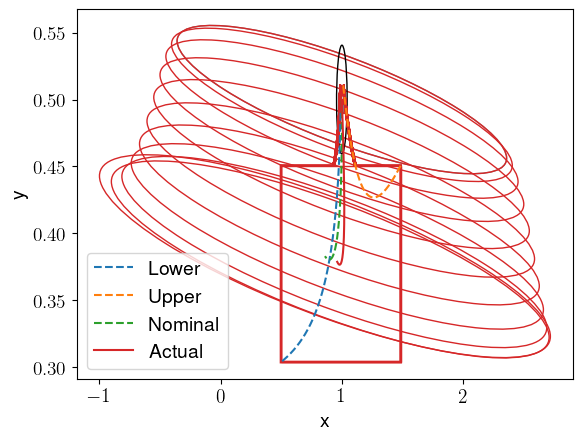

In [ ]:
import shapely.ops as so

# plot trajectories
fig, ax = plt.subplots()

# mixed monotonicity tube
plt.plot(xx[:,0], xx[:,1], label='Lower', linestyle="dashed")
plt.plot(xx[:,5], xx[:,6], label='Upper', linestyle="dashed")
plt.plot(xxnom[:,0], xxnom[:,1], label='Nominal', linestyle="dashed")
plt.plot(xa[:,0], xa[:,1], label='Actual')
start_rect = Rectangle((xx[0,0], xx[0,1]), xx[0,5] - xx[0,0], xx[0,6] - xx[0,1], linewidth=1, edgecolor='tab:gray', facecolor='none')
ax.add_patch(start_rect)
end_rect = Rectangle((xx[-1,0], xx[-1,1]), xx[-1,5] - xx[-1,0], xx[-1,6] - xx[-1,1], linewidth=1, edgecolor='tab:red', facecolor='none')
ax.add_patch(end_rect)

# ellipsoidal tube from algorithm
Ellipsoid(P, xxnom[0, :]).plot_projection(ax, color='tab:gray')
tt = jnp.arange(0, T, dt)
for (i, t) in enumerate(tt[::100]):
    Ellipsoid(P/(np.exp(c*t) + (l/(-1*c))*(1 - np.exp(c*t))*gmax), xxnom[100*i, :]).plot_projection(ax, color='tab:red') 
Ellipsoid(P/(np.exp(c*T) + (l/(-1*c))*(1 - np.exp(c*T))*gmax), xxnom[-1, :]).plot_projection(ax, color='tab:red') 


Ellipsoid(orig_P, xxnom[0, :]).plot_projection(ax, color='black')

# TODO: Plot intersection bt/ ellipsoids and rectangles
irx.utils.draw_iarrays(ax, [irx.ut2i(xxi) for xxi in xx], ec='tab:red')

plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()


